AUTOENCODER


In [ ]:
%tensorflow_version 2.x

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [ ]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [ ]:
from tensorflow import keras

In [ ]:
(x_train,_), (x_test,_)=keras.dataset.load()
#normilize datset to 0,1 range
x_train=x_train/255.0
x_test=x_test/255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#creating encoder
encoder= keras.models.Sequential([
    #flatten the input images 28,28 into 1d arrary of 784 elements
    keras.layers.Flatten(input_shape=[28,28]),
    #add dense layer with 100 neurans and relu function
    keras.layers.Dense(100, activation='relu'),
    #iit has 30  neurans
    keras.layers.Dense(30, activation='relu')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
#crating decoder
decoder=keras.models.Sequential([
    #add a dense layer with 100 neurans and relu activation function input shape is
    keras.layers.Dense(100, activation='relu', input_shape=[30]),
    #add dense layer with 784 neurans (28*28) and sigmoid activation function to output
    keras.layers.Dense(28*28, activation="sigmoid"),
    #reshape the output into the original images shape (28,28)
    keras.layers.Reshape([28,28])
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
stacked_autoencoder= keras.models.Sequential([encoder,decoder])

In [ ]:
#now we compile the model
stacked_autoencoder.compile(
    loss="binary_crossentropy",
    optimizer='adam'
)

In [ ]:
history=stacked_autoencoder.fit(
    x_train, x_train,
    epochs=10,
    validation_data=[x_test,x_test]
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.1957 - val_loss: 0.1084
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.1062 - val_loss: 0.0971
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0976 - val_loss: 0.0934
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0944 - val_loss: 0.0915
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0925 - val_loss: 0.0913
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0910 - val_loss: 0.0892
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0899 - val_loss: 0.0888
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0894 - val_loss: 0.0880
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0889 - val_loss: 0.0877
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0884 - val_loss: 0.0869


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


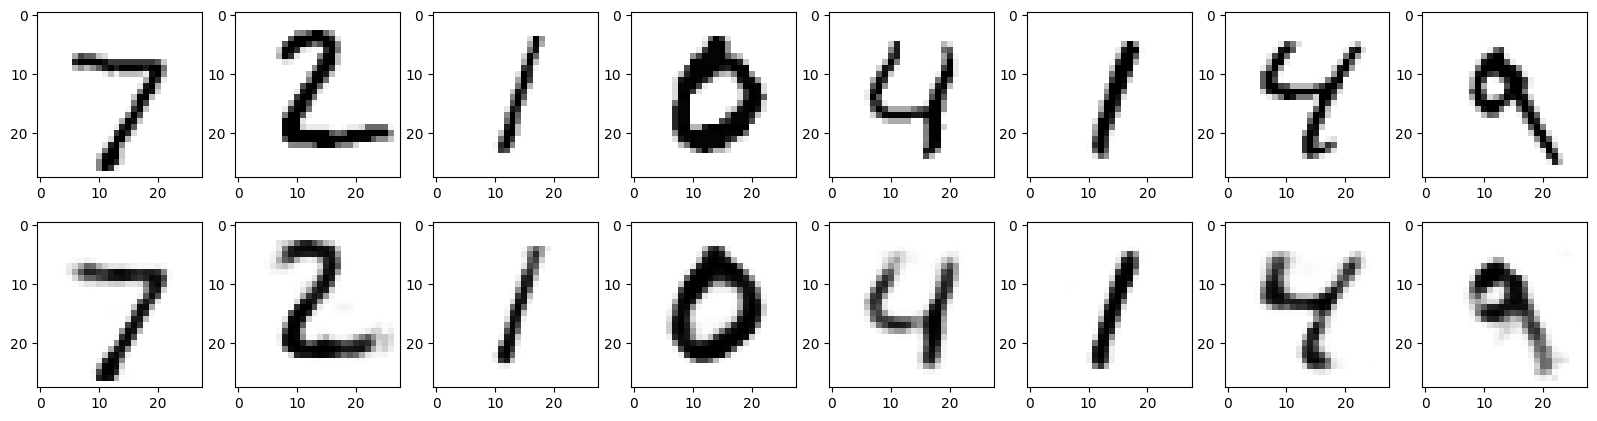

In [ ]:
figsize(20,5)
for i in range (8):
  subplot(2,8,i+1),
  pred=stacked_autoencoder.predict(x_test[i].reshape((1,28,28)))
  imshow(x_test[i], cmap='binary')

  subplot(2,8,i+8+1)
  imshow(pred.reshape((28,28)), cmap="binary")

In [ ]:
sparsity_low=30/(28*28)
sparsity_high=1-20/(28*28)
print(sparsity_low,sparsity_high)


0.03826530612244898 0.9744897959183674


CONVOLUTIONAL AUTO ENCODERS


In [ ]:
encoder=keras.models.Sequential([
    keras.layers.Reshape([28,28,1], input_shape=[28,28]),
    keras.layers.Conv2D(16, kernel_size=(3,3), padding="same", activation='relu'),
    keras.layers.MaxPool2D(pool_size=2),
    keras.layers.Conv2D(32, kernel_size=(3,3), padding="same", activation='relu'),
    keras.layers.MaxPool2D(pool_size=2),
    keras.layers.Conv2D(64, kernel_size=(3,3), padding="same", activation='relu'),
    keras.layers.MaxPool2D(pool_size=2),


])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
encoder.predict(x_test[30].reshape((1,28,28))).shape
#when you multiply this all you have num of flatten layes how many neuranes it conatins

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


(1, 3, 3, 64)

In [ ]:
decoder=keras.models.Sequential([
    keras.layers.Conv2DTranspose(32,kernel_size=(3,3), strides=2, padding="valid", activation='relu', input_shape=[3,3,64]),
    keras.layers.Conv2DTranspose(16,kernel_size=(3,3), strides=2, padding="same", activation='relu'),
    keras.layers.Conv2DTranspose(1,kernel_size=(3,3), strides=2, padding="same", activation='sigmoid'),
    keras.layers.Reshape([28,28])
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv_transpose.py:94: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


In [ ]:
stacked_autoencoder=keras.models.Sequential([encoder, decoder])

In [ ]:
stacked_autoencoder.compile(
    loss="binary_crossentropy",
    optimizer='adam'
)

In [ ]:
history=stacked_autoencoder.fit(
    x_train,x_train,
    epochs=10,
    validation_data=[x_test, x_test]
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - loss: 0.1930 - val_loss: 0.0849
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - loss: 0.0839 - val_loss: 0.0785
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - loss: 0.0784 - val_loss: 0.0760
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - loss: 0.0761 - val_loss: 0.0739
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - loss: 0.0747 - val_loss: 0.0729
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - loss: 0.0734 - val_loss: 0.0727
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - loss: 0.0728 - val_loss: 0.0715
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - loss: 0.0722 - val_loss: 0.0715
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - loss: 0.0717 - val_loss: 0.0713
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - loss: 0.0714 - val_loss: 0.0709


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


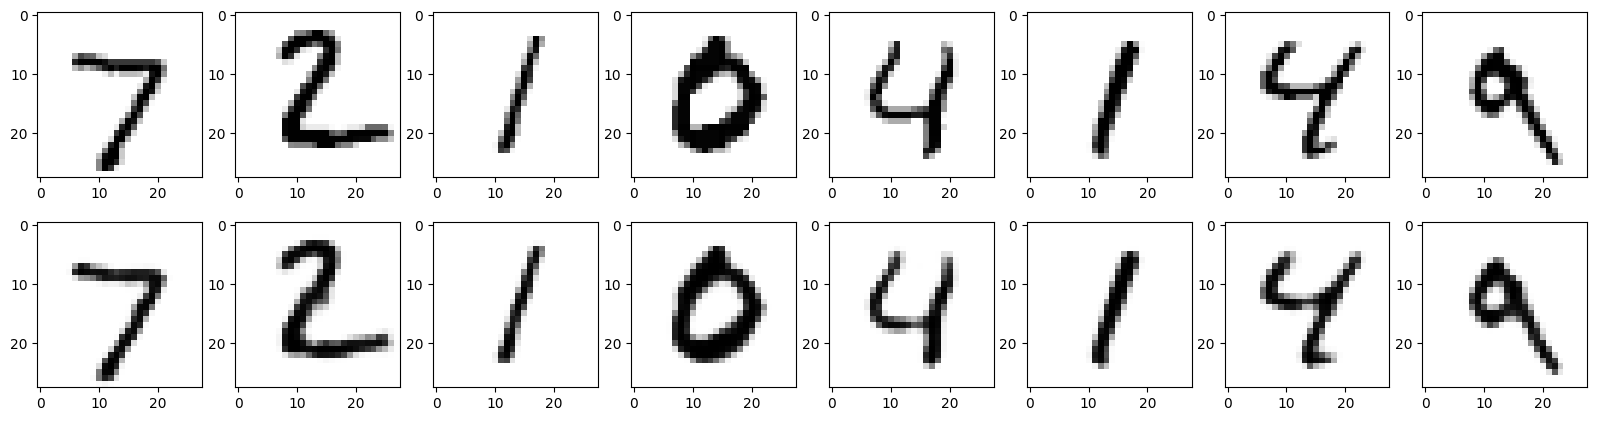

In [ ]:
figsize(20,5)
for i in range (8):
  subplot(2,8,i+1),
  pred=stacked_autoencoder.predict(x_test[i].reshape((1,28,28)))
  imshow(x_test[i], cmap='binary')

  subplot(2,8,i+8+1)
  imshow(pred.reshape((28,28)), cmap="binary")

DENOISING AUTOENCODERS


In [ ]:
import numpy as np


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


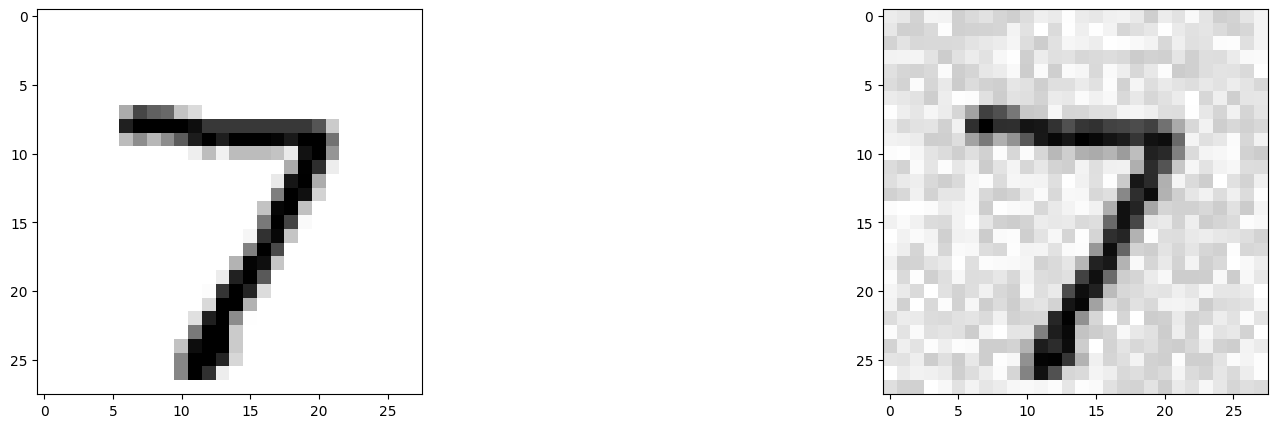

In [ ]:
figsize(20,5)
subplot(1,2,1),
pred=stacked_autoencoder.predict(x_test[i].reshape((1,28,28)))
imshow(x_test[0], cmap='binary')

subplot(1,2,2)
imshow(x_test[0], cmap="binary")

subplot(1,2,2)
noise=np.random.random((28,28))/4
imshow(x_test[0] + noise, cmap="binary")

In [ ]:
#creating encoder
encoder= keras.models.Sequential([
    #flatten the input images 28,28 into 1d arrary of 784 elements
    keras.layers.Flatten(input_shape=[28,28]),
    #add dense layer with 100 neurans and relu function
    keras.layers.Dense(100, activation='relu'),
    #iit has 30  neurans
    keras.layers.Dense(30, activation='relu')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
#crating decoder
decoder=keras.models.Sequential([
    #add a dense layer with 100 neurans and relu activation function input shape is
    keras.layers.Dense(100, activation='relu', input_shape=[30]),
    #add dense layer with 784 neurans (28*28) and sigmoid activation function to output
    keras.layers.Dense(28*28, activation="sigmoid"),
    #reshape the output into the original images shape (28,28)
    keras.layers.Reshape([28,28])
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
stacked_autoencoder= keras.models.Sequential([encoder, decoder])

In [ ]:
stacked_autoencoder.compile(
    loss="binary_crossentropy",
    optimizer='adam'
)

In [ ]:
x_train_noise=x_train+((np.random.random(x_train.shape))/4)
x_test_noise=x_test+((np.random.random(x_test.shape))/4)


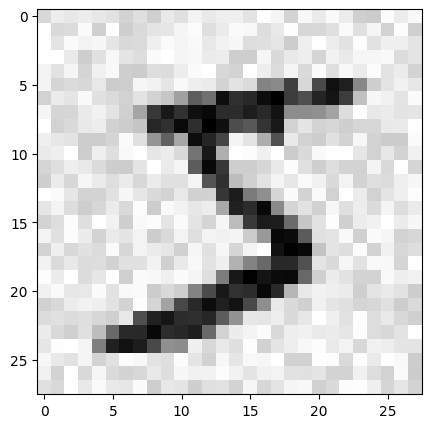

In [ ]:
imshow(x_train_noise[0], cmap="binary")

In [ ]:
history=stacked_autoencoder.fit(
    x_train_noise, x_train,
    epochs=10,
    validation_data=[x_test_noise, x_test]
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.2055 - val_loss: 0.1168
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1147 - val_loss: 0.1066
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1063 - val_loss: 0.1025
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1028 - val_loss: 0.1001
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1008 - val_loss: 0.0985
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0995 - val_loss: 0.0986
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0985 - val_loss: 0.0968
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0975 - val_loss: 0.0962
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.0970 - val_loss: 0.0962
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 0.0966 - val_loss: 0.0955


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


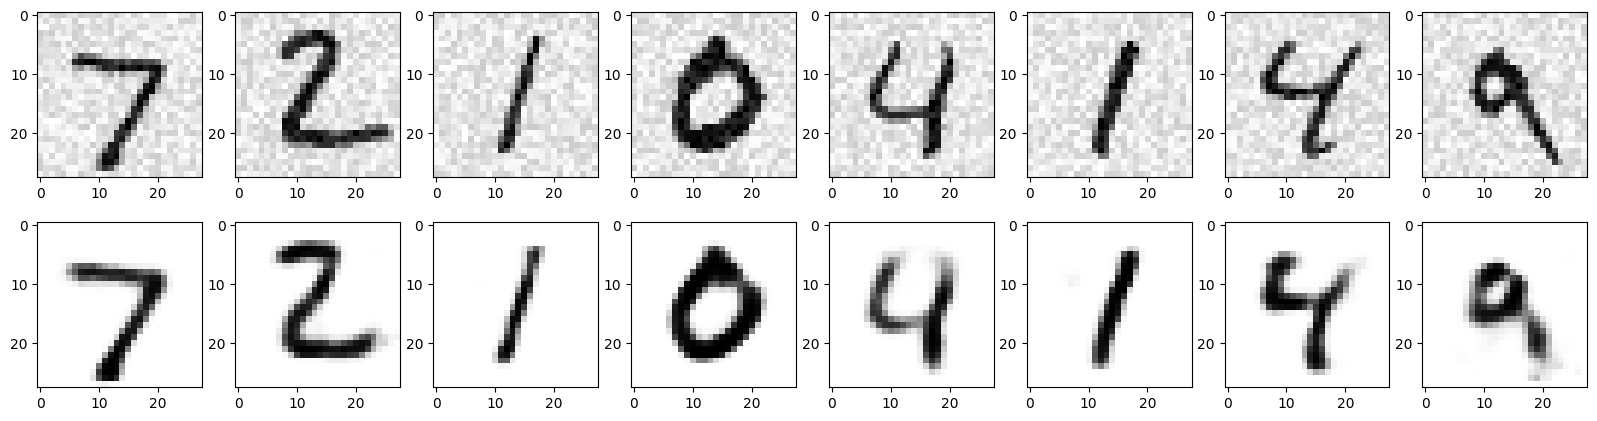

In [ ]:
figsize(20,5)
for i in range (8):
  subplot(2,8,i+1),

  imshow(x_test_noise[i], cmap='binary')

  subplot(2,8,i+8+1)
  pred=stacked_autoencoder.predict(x_test_noise[i].reshape((1,28,28)))
  imshow(pred.reshape((28,28)), cmap="binary")